# Análisis de viabilidad de FIREDpy para Uruguay

Este notebook audita el contenido de `uruguay.zip` y evalúa si los eventos delineados por FIREDpy pueden utilizarse como posible variable objetivo a nivel departamento–semana. No entrena modelos ni modifica los datasets actuales.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RUTA_ZIP = Path("uruguay.zip")
RUTA_RAW = Path("data/raw/firedpy_uruguay")
RUTA_EVENTOS = RUTA_RAW / "fired_uruguay_2000_to_2024_events.gpkg"
RUTA_DIARIA = RUTA_RAW / "fired_uruguay_2000_to_2024_daily.gpkg"
RUTA_METADATA = RUTA_RAW / "fired_uruguay_2000_to_2024_README.txt"
RUTA_DEPARTAMENTOS = Path("geoBoundaries-URY-ADM1-all/geoBoundaries-URY-ADM1.geojson")
RUTA_METEO = Path("data/processed/open_meteo_department_weekly/open_meteo_department_weekly_2017_2025.parquet")
RUTA_FIRMS = Path("results/data/firms_departamento_semana_clean.parquet")
RUTA_MIRA = Path("incendios_forestales_mira_0.csv")
for ruta in [RUTA_ZIP, RUTA_RAW, RUTA_EVENTOS, RUTA_DIARIA, RUTA_METADATA, RUTA_DEPARTAMENTOS]:
    assert ruta.exists(), f"No se encontró {ruta}"

## 1. Contenido real del ZIP

In [2]:
with ZipFile(RUTA_ZIP) as archivo_zip:
    inventario_zip = pd.DataFrame([{
        "archivo": info.filename, "tamaño_bytes": info.file_size,
        "extensión": Path(info.filename).suffix.lower(),
    } for info in archivo_zip.infolist()])
print("ZIP:", RUTA_ZIP.resolve())
print("Tamaño ZIP:", RUTA_ZIP.stat().st_size, "bytes")
display(inventario_zip)
print("Archivos extraídos en:", RUTA_RAW.resolve())
print("Capas del GeoPackage de eventos:")
display(gpd.list_layers(RUTA_EVENTOS))
print("Capas del GeoPackage diario:")
display(gpd.list_layers(RUTA_DIARIA))

ZIP: /home/pepo/Materias/PAA/uruguay.zip
Tamaño ZIP: 11158500 bytes


,archivo,tamaño_bytes,extensión
0,fired_uruguay_2000_to_2024_daily.gpkg,29691904,.gpkg
1,fired_uruguay_2000_to_2024_events.csv,1268176,.csv
2,fired_uruguay_2000_to_2024_README.txt,7440,.txt
3,fired_uruguay_2000_to_2024_events.cpg,5,.cpg
4,fired_uruguay_2000_to_2024_events.dbf,22438346,.dbf
5,fired_uruguay_2000_to_2024_events.gpkg,14299136,.gpkg
6,fired_uruguay_2000_to_2024_events.prj,292,.prj
7,fired_uruguay_2000_to_2024_events.shp,5002556,.shp
8,fired_uruguay_2000_to_2024_events.shx,150308,.shx


Archivos extraídos en: /home/pepo/Materias/PAA/data/raw/firedpy_uruguay
Capas del GeoPackage de eventos:


,name,geometry_type
0,fired_uruguay_2000_to_2024_events,MultiPolygon


Capas del GeoPackage diario:


,name,geometry_type
0,fired_uruguay_2000_to_2024_daily,MultiPolygon


El ZIP contiene dos productos geoespaciales: el GeoPackage `events`, con un polígono acumulado por evento, y el GeoPackage `daily`, con un polígono por evento y fecha. El CSV es una tabla reducida de los eventos. Los archivos `.shp`, `.dbf`, `.shx`, `.prj` y `.cpg` forman conjuntamente la versión Shapefile del mismo producto `events`. El README contiene metodología, proyección y diccionario de variables.

## 2. Unidad de observación y metadata

In [3]:
metadata_texto = RUTA_METADATA.read_text(encoding="utf-8", errors="replace")
print(metadata_texto[:5000])

-------------------

ABSTRACT

-------------------

This is event-level polygons for the fire event delineation (FIRED) product for URUGUAY from November 2000  to August 2024. It is derived from the MODIS MCD64A1 burned area product (see https://lpdaac.usgs.gov/products/mcd64a1v061/ for more details). The MCD64A1 is a monthly raster grid of estimated burned dates. Firedpy (https://github.com/earthlab/firedpy) is an algorithm that converts these rasters into events by stacking the entire time series into a spatial-temporal data cube, then uses an algorithm to assign event identification numbers to pixels that fit into the same 3-dimensional spatial temporal window. This particular dataset was created using a spatial parameter of 1 pixels and 5 days. Daily polygons are included and the event identification numbers are the same for both files, but the event-level product has only single polygons for each entire event, while the daily product has separate polygons for each date per event. 

Según el README incluido, **cada fila de `events` es un evento FIRED delineado algorítmicamente**. FIREDpy agrupa píxeles del producto MODIS MCD64A1 de área quemada en un cubo espacio–temporal, utilizando para este extracto una ventana espacial de 1 píxel y temporal de 5 días. `ig_date` es la fecha más temprana del evento y `last_date` la más tardía. La geometría de `events` reúne el perímetro completo del evento; `daily` contiene geometrías separadas por fecha. No es un registro administrativo ni un incendio confirmado por Bomberos.

In [4]:
eventos = gpd.read_file(RUTA_EVENTOS)
capas_diarias = gpd.list_layers(RUTA_DIARIA)
diario_muestra = gpd.read_file(RUTA_DIARIA, rows=5)
print("Eventos:", eventos.shape)
print("Filas del producto diario según metadata de capa:", int(capas_diarias.iloc[0].get("features", 0)) if "features" in capas_diarias.columns else "37.487, verificado al auditar la capa")
print("CRS:", eventos.crs)
print("Tipos geométricos:", eventos.geom_type.value_counts().to_dict())
display(pd.DataFrame({"columna": eventos.columns, "tipo": eventos.dtypes.astype(str).values}))
display(eventos.head())
display(diario_muestra.head())

Eventos: (18776, 32)
Filas del producto diario según metadata de capa: 37.487, verificado al auditar la capa
CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6371007.181,0]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Tipos geométricos: {'MultiPolygon': 18776}


,columna,tipo
0,id,int64
1,ig_date,str
2,ig_day,str
3,ig_month,int64
4,ig_year,int64
5,last_date,str
6,event_dur,int64
7,tot_pix,int64
8,tot_ar_km2,float64
9,fsr_px_dy,float64


,id,ig_date,ig_day,ig_month,ig_year,last_date,event_dur,tot_pix,tot_ar_km2,fsr_px_dy,...,lc_code,lc_mode,lc_name,lc_desc,lc_type,eco_mode,eco_name,eco_type,tot_perim,geometry
0,9,2004-07-14 00:00:00,196,7,2004,2004-07-14 00:00:00,1,2,0.429317,2.0,...,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,1.0,Espinal,WWF Terrestrial Ecoregions of the World,2787.250866,"MULTIPOLYGON (((-5556973.656 -3336779.156, -55..."
1,11,2008-04-18 00:00:00,109,4,2008,2008-04-25 00:00:00,8,16,3.434539,2.0,...,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,9.0,Southern Cone Mesopotamian savanna,WWF Terrestrial Ecoregions of the World,9274.750866,"MULTIPOLYGON (((-5543072.344 -3338169.156, -55..."
2,33,2011-02-09 00:00:00,040,2,2011,2011-02-14 00:00:00,6,3,0.643976,0.5,...,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,1.0,Espinal,WWF Terrestrial Ecoregions of the World,3714.250866,"MULTIPOLYGON (((-5555120.656 -3336779.156, -55..."
3,34,2020-09-16 00:00:00,260,9,2020,2020-09-16 00:00:00,1,3,0.643976,3.0,...,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,1.0,Espinal,WWF Terrestrial Ecoregions of the World,3714.250866,"MULTIPOLYGON (((-5555120.656 -3336779.156, -55..."
4,35,2004-06-09 00:00:00,161,6,2004,2004-06-09 00:00:00,1,1,0.214659,1.0,...,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,1.0,Espinal,WWF Terrestrial Ecoregions of the World,1861.250866,"MULTIPOLYGON (((-5554657.156 -3336779.156, -55..."


,did,id,date,ig_date,ig_day,ig_month,ig_year,last_date,event_day,event_dur,...,ig_utm_y,lc_code,lc_mode,lc_name,lc_desc,lc_type,eco_mode,eco_name,eco_type,geometry
0,00007d205b05de382820e9250474417b,9168,2008-10-24,2008-10-24,298,10,2008,2008-10-26,1,3,...,-3625190.50,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,3.0,Humid Pampas,WWF Terrestrial Ecoregions of the World,"MULTIPOLYGON (((-5531028.156 -3625423.156, -55..."
1,0001700ec53377a2472c5143c0462193,22311,2016-01-15,2016-01-13,013,1,2016,2016-01-15,3,3,...,-3864259.75,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,10.0,Uruguayan savanna,WWF Terrestrial Ecoregions of the World,"MULTIPOLYGON (((-5092271.156 -3864492.406, -50..."
2,0003078c85279675936f22d5892fe4e1,13840,2006-01-10,2006-01-01,001,1,2006,2006-01-11,10,11,...,-3723876.00,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,8.0,Paraná flooded savanna,WWF Terrestrial Ecoregions of the World,"MULTIPOLYGON (((-5482380.656 -3723643.344, -54..."
3,000500f07ffa607a6d592c90c7704cf9,21974,2018-01-19,2018-01-19,019,1,2018,2018-01-20,1,2,...,-3840630.75,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,3.0,Humid Pampas,WWF Terrestrial Ecoregions of the World,"MULTIPOLYGON (((-5388791.156 -3840863.406, -53..."
4,0006fccd6ca5367f532889ed7a04aea3,5798,2021-10-17,2021-10-17,290,10,2021,2021-10-29,1,13,...,-3505655.75,255,255,Unclassified,Has not received a map label because of missin...,IGBP global vegetation classification scheme,10.0,Uruguayan savanna,WWF Terrestrial Ecoregions of the World,"MULTIPOLYGON (((-5146478.656 -3505888.406, -51..."


## 3. Calidad estructural

In [5]:
for columna in ["ig_date", "last_date", "mx_grw_dte"]:
    eventos[columna] = pd.to_datetime(eventos[columna], errors="coerce")
calidad = pd.Series({
    "filas": len(eventos), "columnas": eventos.shape[1],
    "ids_únicos": eventos["id"].nunique(),
    "filas_con_id_repetido": eventos.duplicated("id", keep=False).sum(),
    "duplicados_exactos_sin_geometría": eventos.drop(columns="geometry").duplicated().sum(),
    "geometrías_nulas": eventos.geometry.isna().sum(),
    "geometrías_vacías": eventos.geometry.is_empty.sum(),
    "geometrías_inválidas": (~eventos.geometry.is_valid).sum(),
})
display(calidad.to_frame("valor"))
faltantes = pd.DataFrame({"faltantes": eventos.isna().sum(), "porcentaje": eventos.isna().mean().mul(100).round(3)})
display(faltantes.loc[faltantes["faltantes"].gt(0)].sort_values("faltantes", ascending=False))
print("Bounding box en CRS nativo:", eventos.total_bounds)
print("Diferencias fecha final < fecha inicial:", int(eventos["last_date"].lt(eventos["ig_date"]).sum()))

,valor
filas,18776
columnas,32
ids_únicos,18776
filas_con_id_repetido,0
duplicados_exactos_sin_geometría,0
geometrías_nulas,0
geometrías_vacías,0
geometrías_inválidas,0


,faltantes,porcentaje
eco_mode,120,0.639
eco_name,120,0.639


Bounding box en CRS nativo: [-5559753.15635826 -3966421.15635826 -4905090.84364174 -3335850.09364174]
Diferencias fecha final < fecha inicial: 0


## 4. Cobertura temporal del extracto completo

Fecha inicial: 2000-10-31 00:00:00
Última fecha de inicio: 2024-07-29 00:00:00
Última fecha final: 2024-07-30 00:00:00


,eventos_extracto
ig_date,
2000,96
2001,172
2002,614
2003,862
2004,1401
2005,706
2006,1858
2007,530
2008,2264


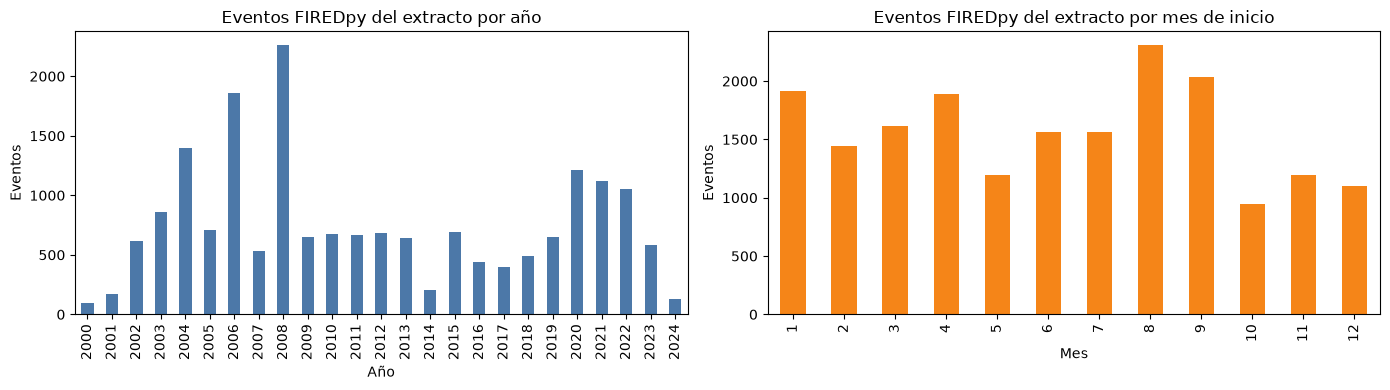

In [6]:
print("Fecha inicial:", eventos["ig_date"].min())
print("Última fecha de inicio:", eventos["ig_date"].max())
print("Última fecha final:", eventos["last_date"].max())
por_anio_extracto = eventos.groupby(eventos["ig_date"].dt.year).size().rename("eventos_extracto")
por_mes_extracto = eventos.groupby(eventos["ig_date"].dt.month).size().rename("eventos_extracto")
display(por_anio_extracto.to_frame())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
por_anio_extracto.plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set(title="Eventos FIREDpy del extracto por año", xlabel="Año", ylabel="Eventos")
por_mes_extracto.plot.bar(ax=axes[1], color="#f58518")
axes[1].set(title="Eventos FIREDpy del extracto por mes de inicio", xlabel="Mes", ylabel="Eventos")
plt.tight_layout(); plt.show()

## 5. Extensión geográfica y asignación departamentalLa capa se transforma al CRS de los departamentos para las relaciones espaciales. Se comparan el departamento del punto estimado de ignición (`x`, `y`, en el CRS nativo) y el departamento con mayor área de intersección. No se modifica la geometría original.

In [7]:
departamentos_wgs84 = gpd.read_file(RUTA_DEPARTAMENTOS).to_crs("EPSG:4326")
departamentos = departamentos_wgs84.to_crs(eventos.crs)
uruguay_union = departamentos.union_all()
eventos["intersecta_uruguay"] = eventos.geometry.intersects(uruguay_union)
eventos["dentro_uruguay"] = eventos.geometry.within(uruguay_union)
pares_departamentos = gpd.sjoin(eventos[["id", "geometry"]], departamentos[["shapeName", "geometry"]], how="left", predicate="intersects")
dentro_departamento = gpd.sjoin(eventos[["id", "geometry"]], departamentos[["shapeName", "geometry"]], how="left", predicate="within")
cantidad_departamentos = pares_departamentos.groupby(level=0)["shapeName"].nunique()
eventos["cantidad_departamentos_intersectados"] = cantidad_departamentos
puntos_ignicion = gpd.GeoDataFrame(eventos[["id"]].copy(), geometry=gpd.points_from_xy(eventos["x"], eventos["y"]), crs=eventos.crs)
asignacion_ignicion = gpd.sjoin(puntos_ignicion, departamentos[["shapeName", "geometry"]], how="left", predicate="within").set_index("id")["shapeName"]
print("Eventos completamente dentro de Uruguay:", int(eventos["dentro_uruguay"].sum()))
print("Eventos completamente dentro de un departamento:", int(dentro_departamento["shapeName"].notna().sum()))
print("Eventos que intersectan Uruguay:", int(eventos["intersecta_uruguay"].sum()))
print("Eventos que cruzan el límite nacional:", int((eventos["intersecta_uruguay"] & ~eventos["dentro_uruguay"]).sum()))
print("Eventos sin intersección con Uruguay:", int((~eventos["intersecta_uruguay"]).sum()))
print("Intersecciones departamentales por evento:", cantidad_departamentos.value_counts().sort_index().to_dict())
print("Puntos de ignición sin departamento:", int(asignacion_ignicion.isna().sum()))

Eventos completamente dentro de Uruguay: 6895
Eventos completamente dentro de un departamento: 6743
Eventos que intersectan Uruguay: 6967
Eventos que cruzan el límite nacional: 72
Eventos sin intersección con Uruguay: 11809
Intersecciones departamentales por evento: {0: 11809, 1: 6815, 2: 152}
Puntos de ignición sin departamento: 11848


In [8]:
pares_validos = pares_departamentos.dropna(subset=["shapeName"])
indices_unicos = cantidad_departamentos[cantidad_departamentos.eq(1)].index
asignacion_mayor = pares_validos.loc[pares_validos.index.isin(indices_unicos)].set_index("id")["shapeName"]
intersecciones_ambiguas = []
for indice in cantidad_departamentos[cantidad_departamentos.gt(1)].index:
    evento = eventos.loc[indice]
    nombres = pares_validos.loc[indice, "shapeName"]
    nombres = [nombres] if isinstance(nombres, str) else nombres.tolist()
    for nombre in nombres:
        poligono = departamentos.loc[departamentos["shapeName"].eq(nombre), "geometry"].iloc[0]
        intersecciones_ambiguas.append({"id": evento["id"], "departamento": nombre, "area_interseccion_m2": evento.geometry.intersection(poligono).area})
tabla_ambiguas = pd.DataFrame(intersecciones_ambiguas)
if not tabla_ambiguas.empty:
    mayor_ambigua = tabla_ambiguas.sort_values("area_interseccion_m2").drop_duplicates("id", keep="last").set_index("id")["departamento"]
    asignacion_mayor = pd.concat([asignacion_mayor, mayor_ambigua])
eventos["departamento_mayor_interseccion"] = eventos["id"].map(asignacion_mayor)
eventos["departamento_ignicion"] = eventos["id"].map(asignacion_ignicion)
comparables = eventos[["departamento_mayor_interseccion", "departamento_ignicion"]].dropna()
print("Asignados por mayor intersección:", eventos["departamento_mayor_interseccion"].notna().sum())
print("Eventos que intersectan más de un departamento:", cantidad_departamentos.gt(1).sum())
print("Diferencias ignición vs mayor intersección entre casos comparables:", comparables.iloc[:, 0].ne(comparables.iloc[:, 1]).sum())

Asignados por mayor intersección: 6967
Eventos que intersectan más de un departamento: 152
Diferencias ignición vs mayor intersección entre casos comparables: 14


El extracto nominal de Uruguay contiene numerosos eventos que no intersectan el país, probablemente porque representa un recorte regional y no un recorte administrativo exacto. Para el panel exploratorio se adopta el departamento con mayor superficie de intersección. Esta regla conserva los eventos fronterizos y hace explícitos los casos ambiguos; no se presenta como decisión definitiva.

## 6. Área quemada

,tot_ar_km2
count,6967.000000
mean,0.916282
std,2.890417
min,0.214659
1%,0.214659
5%,0.214659
25%,0.214659
50%,0.429317
75%,0.858635
90%,1.717269


Diferencia absoluta máxima entre área geométrica y tot_ar_km2: 0.5974035362860128


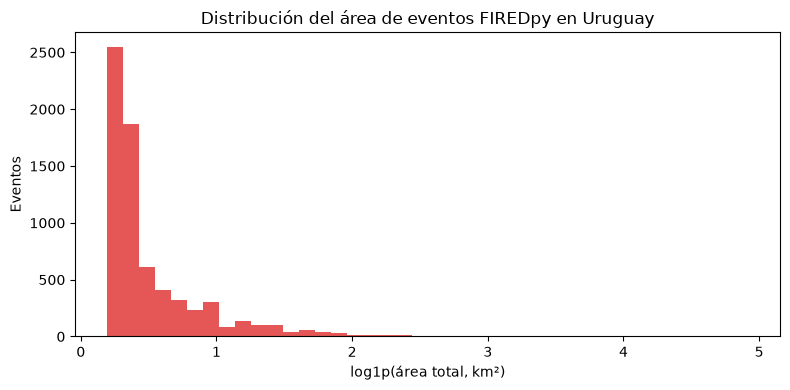

In [9]:
eventos_uruguay = eventos.loc[eventos["departamento_mayor_interseccion"].notna()].copy()
area_resumen = eventos_uruguay["tot_ar_km2"].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])
display(area_resumen.to_frame("tot_ar_km2"))
eventos_uruguay["area_geometria_km2"] = eventos_uruguay.geometry.area / 1_000_000
print("Diferencia absoluta máxima entre área geométrica y tot_ar_km2:", (eventos_uruguay["area_geometria_km2"] - eventos_uruguay["tot_ar_km2"]).abs().max())
fig, ax = plt.subplots(figsize=(8, 4))
np.log1p(eventos_uruguay["tot_ar_km2"]).plot.hist(bins=40, ax=ax, color="#e45756")
ax.set(title="Distribución del área de eventos FIREDpy en Uruguay", xlabel="log1p(área total, km²)", ylabel="Eventos")
plt.tight_layout(); plt.show()

`tot_ar_km2` es el área total del evento en km² según la metadata. El cálculo geométrico se realiza en el CRS sinusoidal métrico nativo, no en latitud/longitud. Los extremos se conservan sin filtrado.

## 7. Cobertura uruguaya y vistas temporales

In [10]:
eventos_uruguay["fecha_inicio_semana"] = eventos_uruguay["ig_date"].dt.normalize() - pd.to_timedelta(eventos_uruguay["ig_date"].dt.weekday, unit="D")
meteo = pd.read_parquet(RUTA_METEO)
meteo["fecha_inicio_semana"] = pd.to_datetime(meteo["fecha_inicio_semana"], errors="raise")
inicio_meteo, fin_meteo = meteo["fecha_inicio_semana"].min(), meteo["fecha_inicio_semana"].max()
vista_2018 = eventos_uruguay.loc[eventos_uruguay["ig_date"].ge("2018-01-01")]
vista_comun_meteo = eventos_uruguay.loc[eventos_uruguay["fecha_inicio_semana"].between(inicio_meteo, fin_meteo)]
resumen_vistas = pd.DataFrame({
    "vista": ["Extracto completo", "Intersección con Uruguay", "Uruguay desde 2018", "Uruguay en período Open-Meteo"],
    "eventos": [len(eventos), len(eventos_uruguay), len(vista_2018), len(vista_comun_meteo)],
    "inicio": [eventos["ig_date"].min(), eventos_uruguay["ig_date"].min(), vista_2018["ig_date"].min(), vista_comun_meteo["ig_date"].min()],
    "fin": [eventos["ig_date"].max(), eventos_uruguay["ig_date"].max(), vista_2018["ig_date"].max(), vista_comun_meteo["ig_date"].max()],
})
display(resumen_vistas)
por_anio_uruguay = eventos_uruguay.groupby(eventos_uruguay["ig_date"].dt.year).size().rename("eventos")
display(por_anio_uruguay.to_frame())

,vista,eventos,inicio,fin
0,Extracto completo,18776,2000-10-31,2024-07-29
1,Intersección con Uruguay,6967,2000-10-31,2024-07-29
2,Uruguay desde 2018,1551,2018-01-02,2024-07-29
3,Uruguay en período Open-Meteo,1755,2017-01-06,2024-07-29


,eventos
ig_date,
2000,62
2001,95
2002,330
2003,483
2004,558
2005,265
2006,314
2007,301
2008,556


No hay años totalmente vacíos entre 2000 y 2024, pero 2000 comienza en octubre y 2024 termina en julio, por lo que ambos son parciales. Las variaciones anuales no permiten por sí solas distinguir cambios reales de actividad, detectabilidad MODIS o cobertura del producto; el archivo no contiene una bandera diaria de cobertura.

## 8. Panel exploratorio departamento–semanaSe usa `ig_date`, la fecha más temprana contenida en cada evento. El período del PAA comienza el 01/01/2018. Se excluye la semana final parcial porque su domingo supera la última fecha observada del producto. El área total del evento se asigna al departamento de mayor intersección; no se reparte entre departamentos.

In [11]:
ultima_fecha_observada = eventos_uruguay["last_date"].max().normalize()
ultima_semana = ultima_fecha_observada - pd.to_timedelta(ultima_fecha_observada.weekday(), unit="D")
ultima_semana_completa = ultima_semana if ultima_semana + pd.Timedelta(days=6) <= ultima_fecha_observada else ultima_semana - pd.Timedelta(days=7)
inicio_panel = pd.Timestamp("2018-01-01")
eventos_panel = eventos_uruguay.loc[eventos_uruguay["fecha_inicio_semana"].between(inicio_panel, ultima_semana_completa)].copy()
conteos = eventos_panel.groupby(["departamento_mayor_interseccion", "fecha_inicio_semana"]).agg(
    cantidad_eventos_firedpy=("id", "size"), area_quemada_total=("tot_ar_km2", "sum")
).reset_index().rename(columns={"departamento_mayor_interseccion": "departamento"})
semanas = pd.date_range(inicio_panel, ultima_semana_completa, freq="W-MON")
grilla = pd.MultiIndex.from_product([sorted(departamentos_wgs84["shapeName"].unique()), semanas], names=["departamento", "fecha_inicio_semana"]).to_frame(index=False)
panel = grilla.merge(conteos, on=["departamento", "fecha_inicio_semana"], how="left", validate="one_to_one")
panel[["cantidad_eventos_firedpy", "area_quemada_total"]] = panel[["cantidad_eventos_firedpy", "area_quemada_total"]].fillna(0)
panel["cantidad_eventos_firedpy"] = panel["cantidad_eventos_firedpy"].astype(int)
panel["presencia_firedpy"] = panel["cantidad_eventos_firedpy"].gt(0).astype("int8")
print("Última fecha observada:", ultima_fecha_observada.date())
print("Última semana completa incluida:", ultima_semana_completa.date())
print("Eventos incluidos en panel:", len(eventos_panel))
print("Departamento-semanas:", len(panel))
print("Positivos:", int(panel["presencia_firedpy"].sum()))
print("Negativos:", int(panel["presencia_firedpy"].eq(0).sum()))
print("Porcentaje positivo:", panel["presencia_firedpy"].mean() * 100)
display(panel["cantidad_eventos_firedpy"].describe().to_frame())

Última fecha observada: 2024-07-29
Última semana completa incluida: 2024-07-22
Eventos incluidos en panel: 1550
Departamento-semanas: 6517
Positivos: 893
Negativos: 5624
Porcentaje positivo: 13.702623906705538


,cantidad_eventos_firedpy
count,6517.000000
mean,0.237839
std,0.800682
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,13.000000


In [12]:
panel["anio"] = panel["fecha_inicio_semana"].dt.year
panel["mes"] = panel["fecha_inicio_semana"].dt.month
panel["estacion"] = panel["mes"].map({12: "Verano", 1: "Verano", 2: "Verano", 3: "Otoño", 4: "Otoño", 5: "Otoño", 6: "Invierno", 7: "Invierno", 8: "Invierno", 9: "Primavera", 10: "Primavera", 11: "Primavera"})
def resumen_positivo(columna):
    return panel.groupby(columna).agg(filas=("presencia_firedpy", "size"), positivos=("presencia_firedpy", "sum"), porcentaje=("presencia_firedpy", lambda s: s.mean() * 100), eventos=("cantidad_eventos_firedpy", "sum"))
por_anio_panel = resumen_positivo("anio")
por_departamento_panel = resumen_positivo("departamento").sort_values("positivos", ascending=False)
por_mes_panel = resumen_positivo("mes")
por_estacion_panel = resumen_positivo("estacion")
display(por_anio_panel.round(2)); display(por_departamento_panel.round(2)); display(por_mes_panel.round(2)); display(por_estacion_panel.round(2))
semanas_nacionales = panel.groupby("fecha_inicio_semana")["cantidad_eventos_firedpy"].sum()
print("Semanas con algún evento en Uruguay:", int(semanas_nacionales.gt(0).sum()), "de", len(semanas_nacionales), f"({semanas_nacionales.gt(0).mean()*100:.2f}%)")

,filas,positivos,porcentaje,eventos
anio,,,,
2018,1007,117,11.62,177
2019,988,136,13.77,274
2020,988,204,20.65,354
2021,988,148,14.98,239
2022,988,136,13.77,276
2023,988,122,12.35,191
2024,570,30,5.26,39


,filas,positivos,porcentaje,eventos
departamento,,,,
Rocha,343,104,30.32,181
Treinta y Tres,343,100,29.15,234
Artigas,343,73,21.28,153
Soriano,343,68,19.83,123
Durazno,343,64,18.66,104
Colonia,343,61,17.78,129
Rivera,343,58,16.91,82
Cerro Largo,343,52,15.16,76
Paysandú,343,51,14.87,86


,filas,positivos,porcentaje,eventos
mes,,,,
1,608,101,16.61,144
2,532,118,22.18,193
3,570,73,12.81,116
4,589,107,18.17,228
5,589,66,11.21,136
6,551,40,7.26,52
7,589,46,7.81,88
8,513,66,12.87,100
9,475,90,18.95,180


,filas,positivos,porcentaje,eventos
estacion,,,,
Invierno,1653,152,9.20,240
Otoño,1748,246,14.07,480
Primavera,1482,234,15.79,435
Verano,1634,261,15.97,395


Semanas con algún evento en Uruguay: 291 de 343 (84.84%)


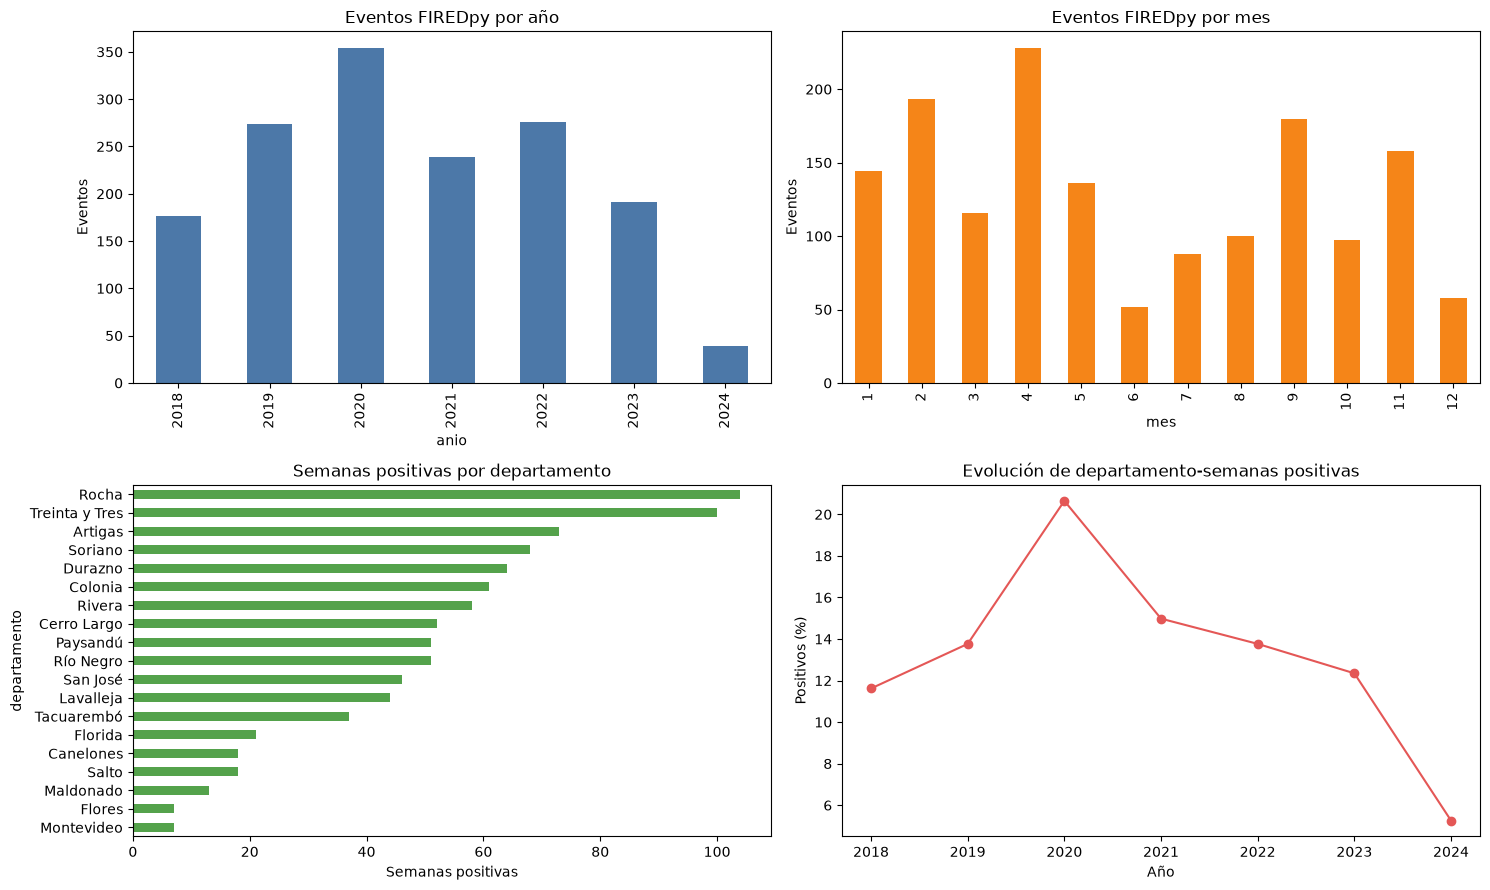

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
por_anio_panel["eventos"].plot.bar(ax=axes[0,0], color="#4c78a8", title="Eventos FIREDpy por año")
por_mes_panel["eventos"].plot.bar(ax=axes[0,1], color="#f58518", title="Eventos FIREDpy por mes")
por_departamento_panel["positivos"].sort_values().plot.barh(ax=axes[1,0], color="#54a24b", title="Semanas positivas por departamento")
por_anio_panel["porcentaje"].plot(ax=axes[1,1], marker="o", color="#e45756", title="Evolución de departamento-semanas positivas")
axes[0,0].set(ylabel="Eventos"); axes[0,1].set(ylabel="Eventos"); axes[1,0].set(xlabel="Semanas positivas"); axes[1,1].set(ylabel="Positivos (%)", xlabel="Año")
plt.tight_layout(); plt.show()

## 9. Mapa exploratorio

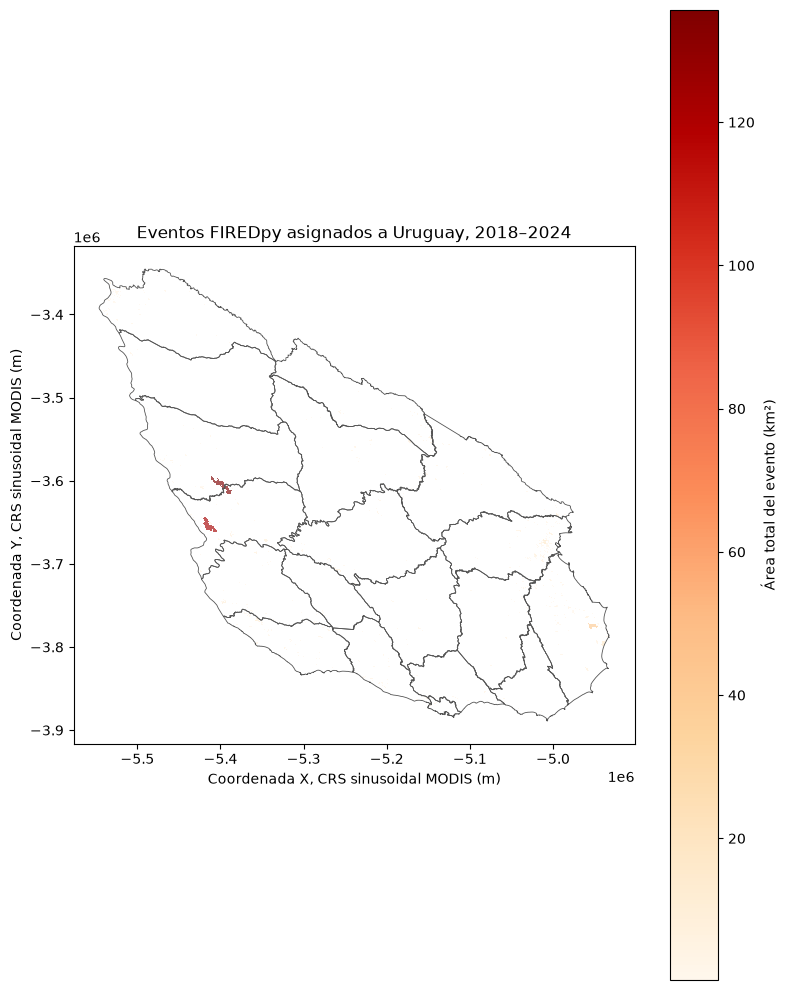

In [14]:
fig, ax = plt.subplots(figsize=(8, 10))
departamentos.boundary.plot(ax=ax, color="#555555", linewidth=0.6)
eventos_panel.plot(ax=ax, column="tot_ar_km2", cmap="OrRd", linewidth=0, alpha=0.65, legend=True, legend_kwds={"label": "Área total del evento (km²)"})
ax.set(title="Eventos FIREDpy asignados a Uruguay, 2018–2024", xlabel="Coordenada X, CRS sinusoidal MODIS (m)", ylabel="Coordenada Y, CRS sinusoidal MODIS (m)")
plt.tight_layout(); plt.show()

## 10. Compatibilidad con Open-Meteo

In [15]:
variables_meteo = ["temperature_2m_max_mean_weekly", "relative_humidity_2m_min_mean_weekly", "wind_speed_10m_max_mean_weekly", "precipitation_sum_weekly"]
claves_meteo = meteo[["departamento", "fecha_inicio_semana"]].drop_duplicates()
compatibilidad = panel[["departamento", "fecha_inicio_semana"]].merge(claves_meteo, on=["departamento", "fecha_inicio_semana"], how="left", indicator=True, validate="one_to_one")
print("Período del panel FIREDpy:", panel["fecha_inicio_semana"].min().date(), "a", panel["fecha_inicio_semana"].max().date())
print("Claves FIREDpy:", len(panel))
print("Claves meteorológicas totales:", len(claves_meteo))
print("Claves FIREDpy compatibles:", compatibilidad["_merge"].eq("both").sum())
print("Porcentaje compatible:", compatibilidad["_merge"].eq("both").mean() * 100)
print("Faltantes tras merge exploratorio:", compatibilidad["_merge"].ne("both").sum())
print("Variables meteorológicas faltantes:", [c for c in variables_meteo if c not in meteo.columns] or "ninguna")

Período del panel FIREDpy: 2018-01-01 a 2024-07-22
Claves FIREDpy: 6517
Claves meteorológicas totales: 8911
Claves FIREDpy compatibles: 6517
Porcentaje compatible: 100.0
Faltantes tras merge exploratorio: 0
Variables meteorológicas faltantes: ninguna


## 11. Concordancia departamento–semana con FIRMSLa comparación siguiente describe acuerdo entre productos. FIREDpy no se trata como verdad de referencia, por lo que no se utilizan términos como verdadero/falso positivo, sensibilidad o especificidad.

firms_positivo,FIRMS negativo,FIRMS positivo
presencia_firedpy,,
FIREDpy negativo,3698,1926
FIREDpy positivo,398,495


Semanas FIREDpy positivas con FIRMS positivo: 495
Semanas FIREDpy positivas con FIRMS cero: 398
Concordancia FIRMS dentro de FIREDpy positivas: 55.43113101903695


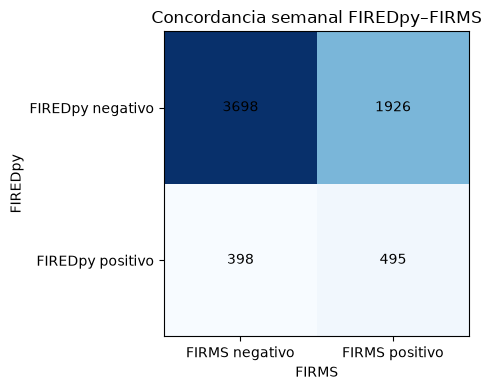

In [16]:
firms = pd.read_parquet(RUTA_FIRMS)
firms["fecha_inicio_semana"] = pd.to_datetime(firms["fecha_inicio_semana"], errors="raise")
comparacion = panel.merge(firms[["departamento", "fecha_inicio_semana", "cantidad_detecciones"]], on=["departamento", "fecha_inicio_semana"], how="left", validate="one_to_one")
assert comparacion["cantidad_detecciones"].notna().all()
comparacion["firms_positivo"] = comparacion["cantidad_detecciones"].gt(0)
tabla_concordancia = pd.crosstab(comparacion["presencia_firedpy"].map({0: "FIREDpy negativo", 1: "FIREDpy positivo"}), comparacion["firms_positivo"].map({False: "FIRMS negativo", True: "FIRMS positivo"}))
display(tabla_concordancia)
fired_positivos = comparacion.loc[comparacion["presencia_firedpy"].eq(1)]
print("Semanas FIREDpy positivas con FIRMS positivo:", int(fired_positivos["firms_positivo"].sum()))
print("Semanas FIREDpy positivas con FIRMS cero:", int((~fired_positivos["firms_positivo"]).sum()))
print("Concordancia FIRMS dentro de FIREDpy positivas:", fired_positivos["firms_positivo"].mean() * 100)
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(tabla_concordancia, cmap="Blues")
for i in range(tabla_concordancia.shape[0]):
    for j in range(tabla_concordancia.shape[1]): ax.text(j, i, int(tabla_concordancia.iloc[i,j]), ha="center", va="center")
ax.set_xticks(range(2), tabla_concordancia.columns); ax.set_yticks(range(2), tabla_concordancia.index); ax.set(title="Concordancia semanal FIREDpy–FIRMS", xlabel="FIRMS", ylabel="FIREDpy")
plt.tight_layout(); plt.show()

## 12. Contraste exploratorio con MIRA

In [17]:
if RUTA_MIRA.exists():
    mira = pd.read_csv(RUTA_MIRA, encoding="utf-8-sig")
    mira["fecha_mira"] = pd.to_datetime(mira["Fecha de registro del evento"], format="%m/%d/%Y %I:%M:%S %p")
    mira["fecha_inicio_semana"] = mira["fecha_mira"].dt.normalize() - pd.to_timedelta(mira["fecha_mira"].dt.weekday, unit="D")
    def normalizar_nombre(valor):
        texto = unicodedata.normalize("NFKD", str(valor)).encode("ascii", "ignore").decode().lower()
        return re.sub(r"[^a-z]", "", texto)
    mapa_departamentos = {normalizar_nombre(d): d for d in departamentos_wgs84["shapeName"]}
    mira["departamento"] = mira["Departamento"].map(lambda x: mapa_departamentos.get(normalizar_nombre(x)))
    cruce_mira = mira.merge(panel[["departamento", "fecha_inicio_semana", "presencia_firedpy"]], on=["departamento", "fecha_inicio_semana"], how="left")
    eventos_uruguay["departamento_norm"] = eventos_uruguay["departamento_mayor_interseccion"]
    coincide_7d_departamento = []
    for _, registro in mira.iterrows():
        coincide_7d_departamento.append(((eventos_uruguay["departamento_norm"] == registro["departamento"]) & (eventos_uruguay["ig_date"].sub(registro["fecha_mira"].normalize()).dt.days.abs().le(7))).any())
    puntos_mira = gpd.GeoDataFrame(mira.copy(), geometry=gpd.points_from_xy(mira["x"], mira["y"]), crs="EPSG:4326").to_crs(eventos.crs)
    coincide_7d_25km = []
    for indice, registro in puntos_mira.iterrows():
        candidatas = eventos_uruguay.loc[eventos_uruguay["ig_date"].sub(registro["fecha_mira"].normalize()).dt.days.abs().le(7)]
        coincide_7d_25km.append(bool(len(candidatas) and candidatas.geometry.distance(registro.geometry).le(25_000).any()))
    print("MIRA con FIREDpy en mismo departamento y semana:", int(cruce_mira["presencia_firedpy"].fillna(0).sum()), "de", len(mira))
    print("MIRA con FIREDpy en mismo departamento y ±7 días:", int(sum(coincide_7d_departamento)), "de", len(mira))
    print("MIRA con polígono FIREDpy a ≤25 km y ±7 días:", int(sum(coincide_7d_25km)), "de", len(mira))
else:
    print("El CSV MIRA no está disponible; contraste omitido.")

MIRA con FIREDpy en mismo departamento y semana: 34 de 113
MIRA con FIREDpy en mismo departamento y ±7 días: 51 de 113
MIRA con polígono FIREDpy a ≤25 km y ±7 días: 37 de 113


## 13. Diferencias entre las fuentes

- **FIRMS:** detecta anomalías térmicas o fuego activo por satélite. No equivale automáticamente a incendios confirmados.
- **MIRA:** el CSV analizado reúne incendios registrados a partir de `sgsp`, `cecoed` y `prensa`, pero presenta cobertura aparentemente incompleta y no contiene un estado uniforme de validación.
- **FIREDpy:** convierte píxeles de fecha de área quemada MODIS MCD64A1 en eventos espacio–temporales y polígonos. Representa eventos derivados de un producto satelital, no confirmaciones administrativas.

FIREDpy sería conceptualmente más próximo que FIRMS a un objetivo de **presencia de evento de área quemada**, porque agrupa píxeles en eventos y aporta perímetro, duración y área. Sin embargo, sigue derivando de observación satelital y su resolución, detectabilidad y algoritmo forman parte de la definición del target.

## 14. Conclusiones sobre la viabilidad de FIREDpy para el PAA

1. El archivo de eventos contiene **18.776 filas**, pero solo **6.967 eventos intersectan Uruguay** según geoBoundaries; el resto pertenece al recorte regional del archivo.
2. Los eventos asignables a Uruguay van del **31/10/2000 al 29/07/2024**. Los años 2000 y 2024 son parciales.
3. Desde 2018 hay **1.551 eventos uruguayos**. El panel de semanas completas incluye 1.550 porque excluye la semana parcial iniciada el 29/07/2024.
4. El panel 2018–22/07/2024 produce **893 departamento-semanas positivas**.
5. Son **6.517 filas**, con **13,70% positivas** y 86,30% negativas. Es sustancialmente menos extremo que las 75 celdas positivas del escenario MIRA.
6. Hay eventos en todos los años, y 291 de 343 semanas completas contienen al menos un evento en Uruguay. No obstante, el producto no aporta una bandera de cobertura; 2024 es parcial y los cambios anuales no deben interpretarse automáticamente como discontinuidades técnicas.
7. Se asignan 6.967 eventos por mayor intersección. Hay 152 que intersectan más de un departamento y 14 casos comparables donde difieren punto de ignición y mayor intersección; la regla debe quedar fijada antes del modelado.
8. Las 6.517 claves del panel encuentran correspondencia en Open-Meteo y están disponibles las cuatro variables meteorológicas actuales.
9. De 893 celdas FIREDpy positivas, **495 también son FIRMS positivas** y 398 tienen FIRMS cero: 55,43% de concordancia FIRMS dentro de las positivas FIREDpy. La tabla completa conserva también las otras dos combinaciones.
10. Entre los 113 registros MIRA, 34 coinciden con FIREDpy en departamento y semana, 51 en el mismo departamento y ±7 días, y 37 tienen un polígono FIREDpy a ≤25 km y ±7 días. Es un contraste exploratorio, no validación.
11. Las limitaciones principales son el recorte regional no administrativo, la resolución MODIS de aproximadamente 463 m, el algoritmo de agrupamiento, eventos fronterizos, años inicial/final parciales, falta de indicador de cobertura y ausencia de confirmación administrativa.
12. `presencia_firedpy` es una alternativa defendible si el objetivo se redefine explícitamente como **presencia de eventos de área quemada derivados de MODIS**. Ofrece mucha más cobertura que MIRA y una unidad de evento más próxima al área quemada que FIRMS. No es necesariamente superior si el objetivo continúa siendo detectar focos térmicos activos, y no debe presentarse como presencia de incendios confirmados. Antes de reformular se debe acordar el fenómeno objetivo y validar la regla departamental.